# Module 3: Exploratory Data Analysis (EDA)

### Course: R Programming - A Comprehensive Guide

**Author:** Kajola Gbenga
**Role:** Data Scientist & AI Engineer

---


## Learning Objectives

By the end of this notebook, you will be able to:

- Compute and interpret descriptive statistics in R
- Summarize data sets using multiple techniques
- Create publication quality visualizations with ggplot2
- Build histograms, boxplots, scatterplots, and bar charts
- Conduct correlation analysis between variables
- Identify trends, patterns, and outliers in real data

## 1. Descriptive Statistics

Descriptive statistics summarize the main features of a data set: central tendency, spread, and shape.

- **Central tendency**: mean, median, mode
- **Spread**: range, variance, standard deviation, IQR
- **Shape**: skewness, kurtosis


In [1]:
data(mtcars)

mean(mtcars$mpg)
median(mtcars$mpg)
sd(mtcars$mpg)
var(mtcars$mpg)
range(mtcars$mpg)
IQR(mtcars$mpg)

# R has no built in mode() for statistical mode, so we write one
get_mode <- function(v) {
  uniq_v <- unique(v)
  uniq_v[which.max(tabulate(match(v, uniq_v)))]
}
get_mode(mtcars$cyl)


[1] 20.09062

[1] 19.2

[1] 6.026948

[1] 36.3241

[1] 10.4 33.9

[1] 7.375

[1] 8

## 2. Data Summarization Techniques

R provides several built in and package based ways to summarize an entire data set at once.

In [2]:
summary(mtcars)                 # base R quick summary

library(dplyr)
mtcars %>%
  summarise(
    mean_mpg = mean(mpg),
    sd_mpg = sd(mpg),
    min_mpg = min(mpg),
    max_mpg = max(mpg)
  )

# Grouped summarization
mtcars %>%
  group_by(cyl) %>%
  summarise(across(c(mpg, hp), list(mean = mean, sd = sd)))


      mpg             cyl             disp             hp       
 Min.   :10.40   Min.   :4.000   Min.   : 71.1   Min.   : 52.0  
 1st Qu.:15.43   1st Qu.:4.000   1st Qu.:120.8   1st Qu.: 96.5  
 Median :19.20   Median :6.000   Median :196.3   Median :123.0  
 Mean   :20.09   Mean   :6.188   Mean   :230.7   Mean   :146.7  
 3rd Qu.:22.80   3rd Qu.:8.000   3rd Qu.:326.0   3rd Qu.:180.0  
 Max.   :33.90   Max.   :8.000   Max.   :472.0   Max.   :335.0  
      drat             wt             qsec             vs        
 Min.   :2.760   Min.   :1.513   Min.   :14.50   Min.   :0.0000  
 1st Qu.:3.080   1st Qu.:2.581   1st Qu.:16.89   1st Qu.:0.0000  
 Median :3.695   Median :3.325   Median :17.71   Median :0.0000  
 Mean   :3.597   Mean   :3.217   Mean   :17.85   Mean   :0.4375  
 3rd Qu.:3.920   3rd Qu.:3.610   3rd Qu.:18.90   3rd Qu.:1.0000  
 Max.   :4.930   Max.   :5.424   Max.   :22.90   Max.   :1.0000  
       am              gear            carb      
 Min.   :0.0000   Min.   :3.000  

Warning message:
"package 'dplyr' was built under R version 4.5.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




mean_mpg,sd_mpg,min_mpg,max_mpg
<dbl>,<dbl>,<dbl>,<dbl>
20.09062,6.026948,10.4,33.9


cyl,mpg_mean,mpg_sd,hp_mean,hp_sd
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,26.66364,4.509828,82.63636,20.93453
6,19.74286,1.453567,122.28571,24.26049
8,15.10000,2.560048,209.21429,50.97689


## 3. Data Visualization with ggplot2

`ggplot2` is R's most powerful visualization package, based on the **Grammar of Graphics**. Every plot is built by layering:
1. Data
2. Aesthetic mappings (`aes()`)
3. Geometric objects (`geom_*()`)
4. Optional scales, themes, and facets


Warning message:
"package 'ggplot2' was built under R version 4.5.3"


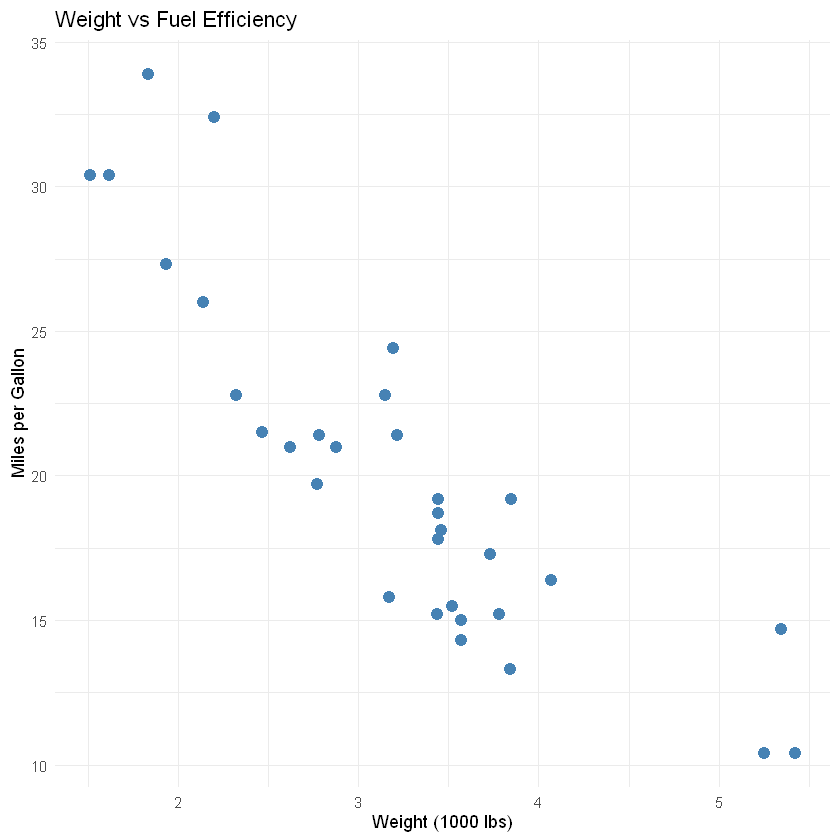

In [3]:
library(ggplot2)

ggplot(mtcars, aes(x = wt, y = mpg)) +
  geom_point(color = "steelblue", size = 3) +
  labs(title = "Weight vs Fuel Efficiency", x = "Weight (1000 lbs)", y = "Miles per Gallon") +
  theme_minimal()


## 4. Histograms, Boxplots, Scatterplots, and Bar Charts

These four charts are the everyday workhorses of exploratory data analysis, each answering a different question about your data.

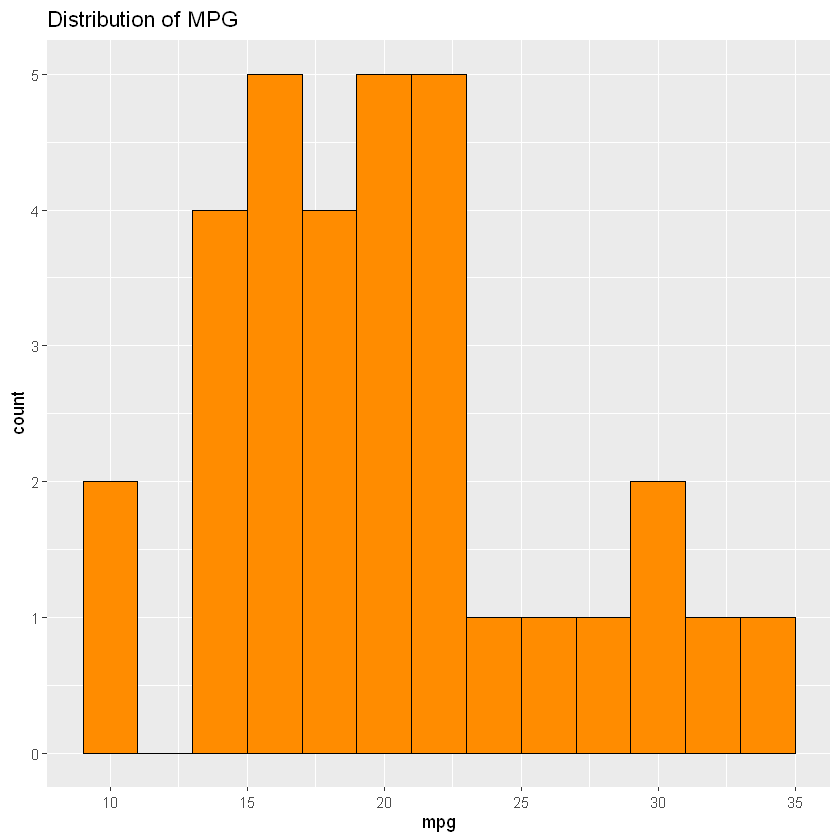

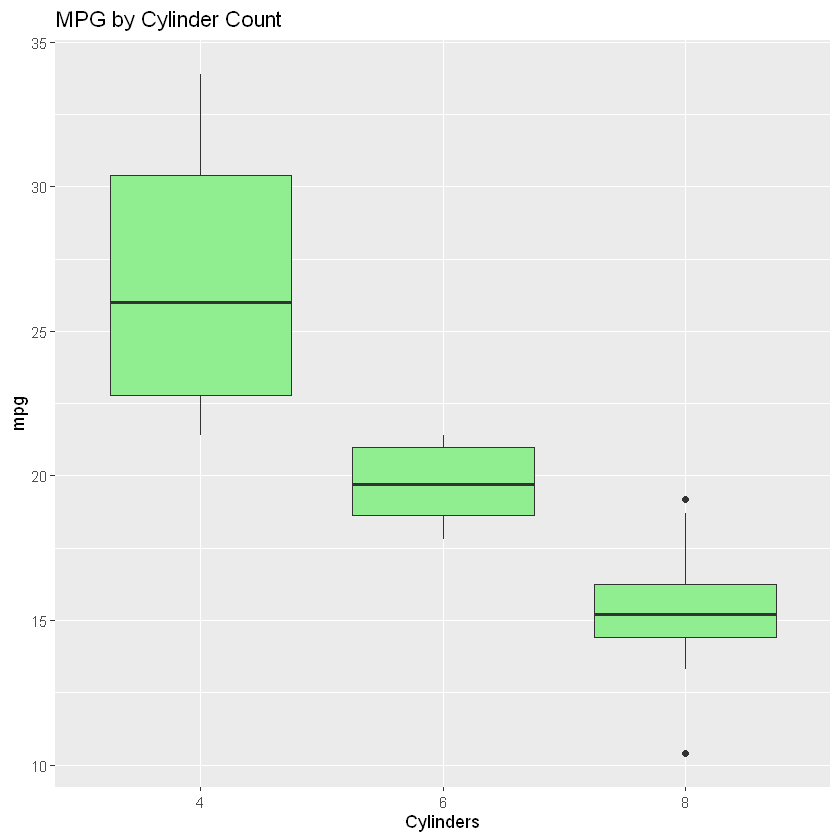

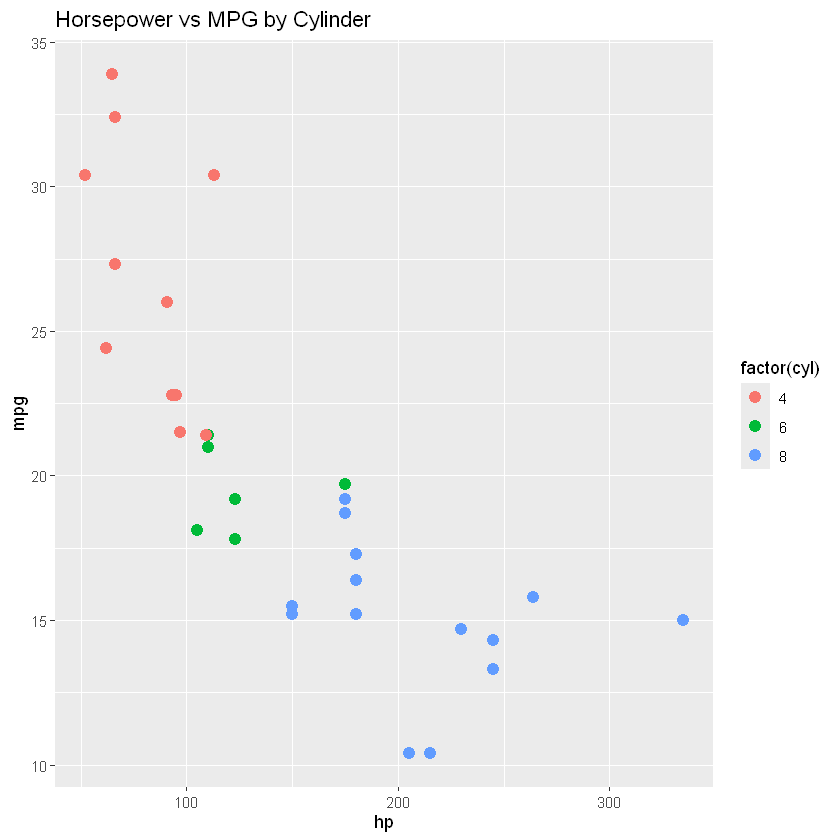

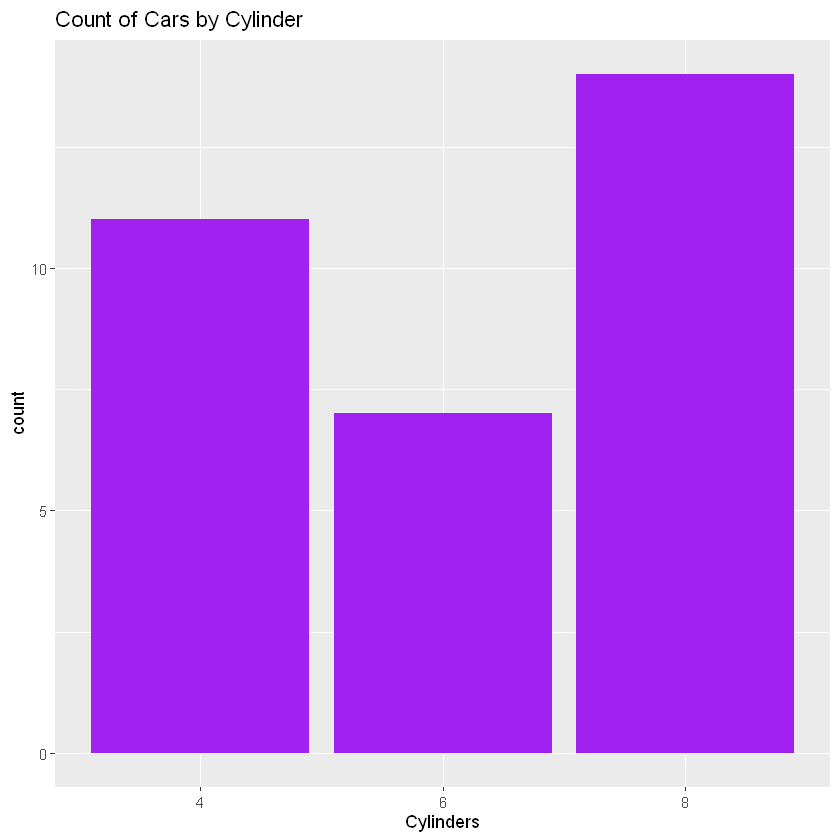

In [4]:
library(ggplot2)

# Histogram - distribution of a single numeric variable
ggplot(mtcars, aes(x = mpg)) +
  geom_histogram(binwidth = 2, fill = "darkorange", color = "black") +
  labs(title = "Distribution of MPG")

# Boxplot - spread and outliers across groups
ggplot(mtcars, aes(x = factor(cyl), y = mpg)) +
  geom_boxplot(fill = "lightgreen") +
  labs(title = "MPG by Cylinder Count", x = "Cylinders")

# Scatterplot - relationship between two numeric variables
ggplot(mtcars, aes(x = hp, y = mpg, color = factor(cyl))) +
  geom_point(size = 3) +
  labs(title = "Horsepower vs MPG by Cylinder")

# Bar chart - counts or totals across categories
ggplot(mtcars, aes(x = factor(cyl))) +
  geom_bar(fill = "purple") +
  labs(title = "Count of Cars by Cylinder", x = "Cylinders")


## 5. Correlation Analysis

Correlation measures the strength and direction of a linear relationship between two numeric variables. Values range from -1 (perfect negative) to +1 (perfect positive), with 0 meaning no linear relationship.

[1] -0.7761684

,mpg,hp,wt,disp
mpg,1.0000000,-0.7761684,-0.8676594,-0.8475514
hp,-0.7761684,1.0000000,0.6587479,0.7909486
wt,-0.8676594,0.6587479,1.0000000,0.8879799
disp,-0.8475514,0.7909486,0.8879799,1.0000000


Warning message:
"package 'corrplot' was built under R version 4.5.3"
corrplot 0.95 loaded




	Pearson's product-moment correlation

data:  mtcars$mpg and mtcars$hp
t = -6.7424, df = 30, p-value = 1.788e-07
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.8852686 -0.5860994
sample estimates:
       cor 
-0.7761684 


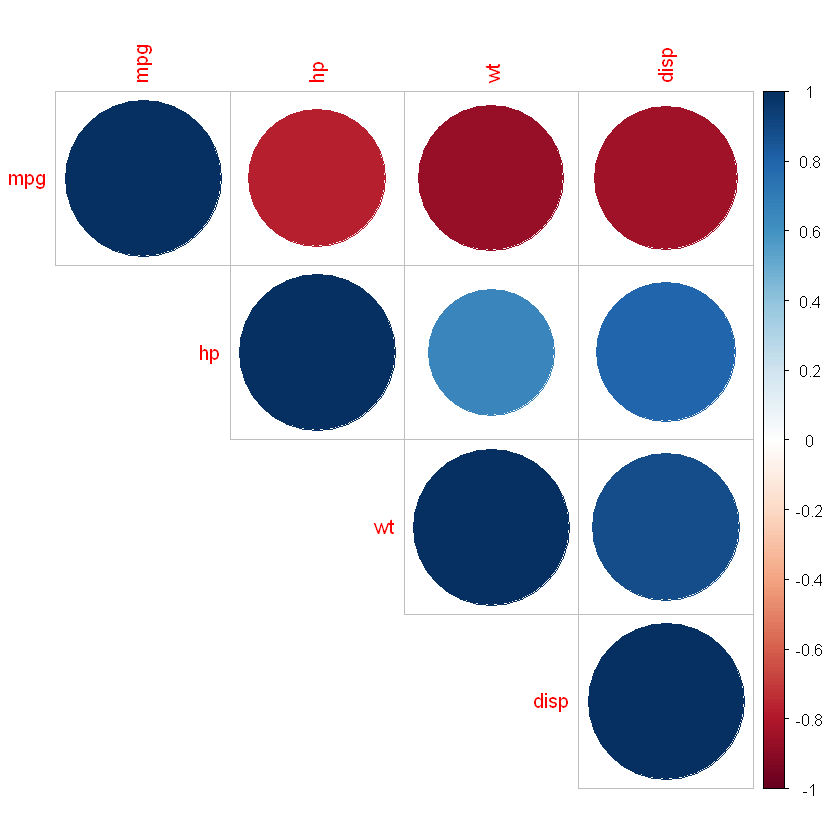

In [5]:
cor(mtcars$mpg, mtcars$hp)                 # Pearson correlation - single pair
cor(mtcars[, c("mpg", "hp", "wt", "disp")]) # correlation matrix

# Visualizing a correlation matrix
# install.packages("corrplot")
library(corrplot)
corr_matrix <- cor(mtcars[, c("mpg", "hp", "wt", "disp")])
corrplot(corr_matrix, method = "circle", type = "upper")

# Statistical significance of a correlation
cor.test(mtcars$mpg, mtcars$hp)


## 6. Identifying Trends, Patterns, and Outliers

Combining summary statistics and visualizations helps you spot trends (consistent directional changes), patterns (recurring structures), and outliers (unusual points) in a data set.

`geom_smooth()` using formula = 'y ~ x'


,mpg,mpg_z
,<dbl>,"<dbl[,1]>"
Fiat 128,32.4,2.042389
Toyota Corolla,33.9,2.291272


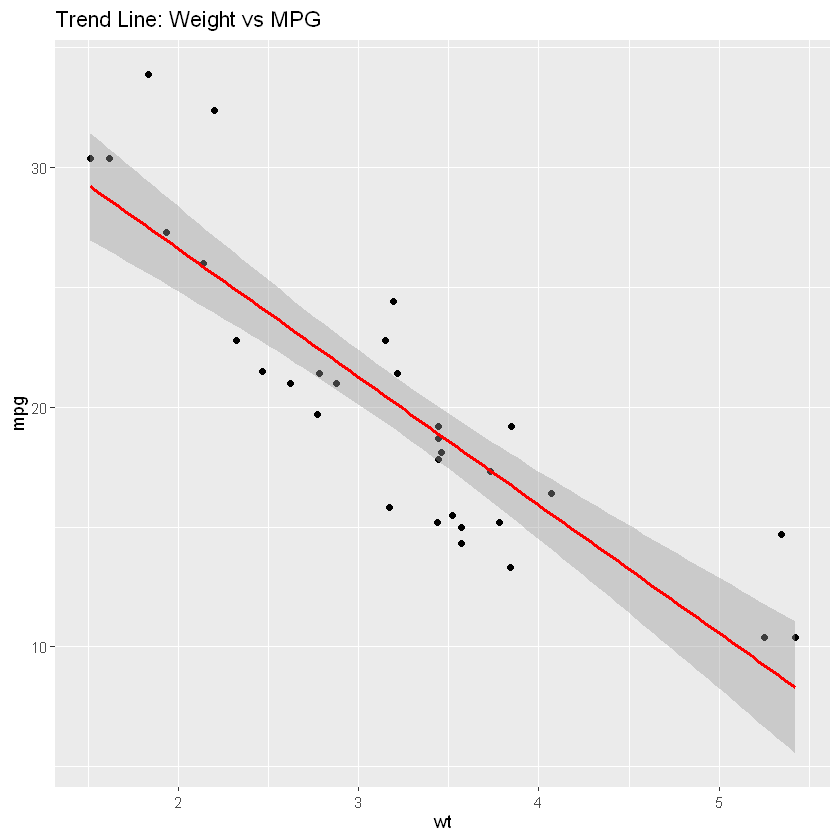

: 

In [ ]:
library(ggplot2)

# Adding a trend line to a scatterplot
ggplot(mtcars, aes(x = wt, y = mpg)) +
  geom_point() +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  labs(title = "Trend Line: Weight vs MPG")

# Flagging outliers using z-scores
mtcars$mpg_z <- scale(mtcars$mpg)
mtcars[abs(mtcars$mpg_z) > 2, c("mpg", "mpg_z")]


## Practice Exercise

1. Compute the full set of descriptive statistics for a numeric column of your choice.
2. Build a histogram, boxplot, scatterplot, and bar chart for a data set of your choice using `ggplot2`.
3. Compute a correlation matrix for at least four numeric variables and interpret the strongest relationship.
4. Identify any outliers in your data set and explain how you would handle them.


---

## Module Summary

This notebook has walked through the core concepts, R code demonstrations, and practice exercises for this module. Review each section, run every code cell yourself, and attempt the practice exercises before moving to the next module.

**Kajola Gbenga**
Data Scientist & AI Engineer